## Today's topics

- T-Test (One-sample & Two-sample)

---

#### **T-TEST**

Use t-test when:

- Population standard deviation is unknown
- Sample size is small (n < 30)

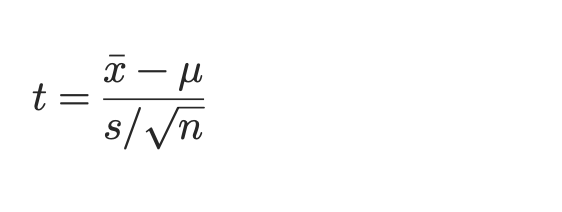


## 🔹 Question 1: One-Sample t-Test (Two-Tailed)

📘 Problem Statement

A coaching institute claims that the average mock test score of students is 70 marks.

A random sample of 12 students has scores:

[68, 72, 75, 69, 71, 73, 70, 74, 67, 72, 69, 71]

At α = 0.05, test whether the average score is different from 70.


In [1]:

import numpy as np
from scipy import stats

# Hypotheses
# H₀: μ = 70
# H₁: μ ≠ 70 (two-tailed)

scores = np.array([68,72,75,69,71,73,70,74,67,72,69,71])
mu = 70
alpha = 0.05

x_bar = np.mean(scores)
s = np.std(scores, ddof=1)
n = len(scores)

t_score = (x_bar - mu) / (s / np.sqrt(n))
p_value = 2 * (1 - stats.t.cdf(abs(t_score), df=n-1))

critical_t = stats.t.ppf(1 - alpha/2, df=n-1)

t_score, p_value, critical_t


(np.float64(1.3071345646941812),
 np.float64(0.21783091895932283),
 np.float64(2.200985160082949))

In [3]:
if p_value < alpha:
    print("Reject H₀: Mean score is significantly different from 70.")
else:
    print("Fail to reject H₀: No significant difference in mean score.")

Fail to reject H₀: No significant difference in mean score.


In [2]:
if (t_score > critical_t) or (t_score < -critical_t):
    print("The t-score falls outside the decision boundary, so we reject the null hypothesis. The sample mean score is significantly different from the claimed average.")
else:
    print("The t-score falls within the decision boundary, so we fail to reject the null hypothesis. The sample mean score is not significantly different from the claimed average.")

The t-score falls within the decision boundary, so we fail to reject the null hypothesis. The sample mean score is not significantly different from the claimed average.



## 🔹 Question 2: One-Sample t-Test (Right-Tailed)

📘 Problem Statement

A startup claims that its average daily sales exceed ₹15,000.

Sample of 10 days:

[14800, 15200, 16000, 15500, 15800, 14900, 15100, 15700, 15900, 15400]


In [4]:
# Hypotheses
# H₀: μ ≤ 15000
# H₁: μ > 15000 (right-tailed)

sales = np.array([14800,15200,16000,15500,15800,14900,15100,15700,15900,15400])
mu = 15000

x_bar = np.mean(sales)
s = np.std(sales, ddof=1)
n = len(sales)

t_score = (x_bar - mu) / (s / np.sqrt(n))
p_value = 1 - stats.t.cdf(t_score, df=n-1)

t_score, p_value


(np.float64(3.2239926596661963), np.float64(0.005211241617425255))

In [5]:

if p_value < alpha:
    print("Reject H₀. Sales have significantly increased.")
else:
    print("Fail to reject H₀")


Reject H₀. Sales have significantly increased.



## 🔹 Question 3: Two-Sample t-Test (Equal Variance / Pooled t-Test)

📘 Problem Statement

Two batches are trained using same syllabus. Compare their average scores.

Batch A =>
Scores: [65, 68, 70, 72, 69]

Batch B =>
Scores: [60, 62, 64, 66, 63]

Assume equal variances.

In [6]:

# Hypotheses
# H₀: μ₁ = μ₂
# H₁: μ₁ ≠ μ₂ (two-tailed)

A = np.array([65,68,70,72,69])
B = np.array([60,62,64,66,63])

t_score, p_value = stats.ttest_ind(A, B, equal_var=True)

df = len(A) + len(B) - 2

critical_t = stats.t.ppf(1 - alpha/2, df=df)

t_score, p_value, critical_t


(np.float64(3.791578612671556),
 np.float64(0.005299886100012601),
 np.float64(2.306004135204166))

In [9]:
if p_value < alpha:
    print("The p-value is less than 0.05, so we reject the null hypothesis. The mean scores of the two batches are significantly different.")
else:
    print("The p-value is greater than or equal to 0.05, so we fail to reject the null hypothesis. There is no significant difference between the batches.")

The p-value is less than 0.05, so we reject the null hypothesis. The mean scores of the two batches are significantly different.


In [8]:
if t_score < -critical_t or t_score > critical_t:
    print("The t-score falls outside the decision boundary, so we reject the null hypothesis. The batch performances differ significantly.")
else:
    print("The t-score falls within the decision boundary, so we fail to reject the null hypothesis. The batch performances do not differ significantly.")

The t-score falls outside the decision boundary, so we reject the null hypothesis. The batch performances differ significantly.



## 🔹 Question 4: Two-Sample t-Test (Welch’s t-Test – Unequal Variance)

📘 Problem Statement

Compare average project completion time of two teams.

Team A => Time (days) [14, 15, 13, 16, 14]

Team B => Time (days) [10, 12, 9, 11, 10, 12]

Variances are not equal.


In [10]:

# Hypotheses
# H₀: μ₁ = μ₂
# H₁: μ₁ ≠ μ₂

team_A = np.array([14,15,13,16,14])
team_B = np.array([10,12,9,11,10,12])

t_score, p_value = stats.ttest_ind(team_A, team_B, equal_var=False)

df = min(len(team_A)-1, len(team_B)-1)
critical_t = stats.t.ppf(1 - alpha/2, df=df)

t_score, p_value, critical_t


(np.float64(5.256420449996041),
 np.float64(0.0005589703847364952),
 np.float64(2.7764451051977987))

In [11]:
if p_value < alpha:
    print("The p-value is less than 0.05, so we reject the null hypothesis. The project completion times differ significantly.")
else:
    print("The p-value is greater than or equal to 0.05, so we fail to reject the null hypothesis. There is no significant difference in completion times.")

The p-value is less than 0.05, so we reject the null hypothesis. The project completion times differ significantly.


In [12]:
if t_score < -critical_t or t_score > critical_t:
    print("The t-score falls outside the decision boundary, so we reject the null hypothesis. The completion times differ significantly.")
else:
    print("The t-score falls within the decision boundary, so we fail to reject the null hypothesis. The completion times do not differ significantly.")

The t-score falls outside the decision boundary, so we reject the null hypothesis. The completion times differ significantly.



## 🔹 Question 5: Two-Sample t-Test (Left-Tailed)

📘 Problem Statement

A new teaching method claims to reduce average learning time.

Method Old => Time (hrs): [9, 10, 11, 9, 10]

Method New => Time (hrs): [7, 8, 7, 9, 8]

In [13]:
# Hypotheses
# H₀: μ_new ≥ μ_old
# H₁: μ_new < μ_old (left-tailed)

old = np.array([9,10,11,9,10])
new = np.array([7,8,7,9,8])

t_score, p_two = stats.ttest_ind(new, old, equal_var=False)
p_value = p_two / 2

df = min(len(old)-1, len(new)-1)

critical_t = stats.t.ppf(alpha, df=df)

t_score, p_value, critical_t


(np.float64(-3.7796447300922744),
 np.float64(0.002695441009757788),
 np.float64(-2.13184678632665))

In [15]:
if p_value < alpha:
    print("The p-value is less than 0.05, so we reject the null hypothesis. The new teaching method significantly reduces learning time.")
else:
    print("The p-value is greater than or equal to 0.05, so we fail to reject the null hypothesis. The new method does not significantly reduce learning time.")

The p-value is less than 0.05, so we reject the null hypothesis. The new teaching method significantly reduces learning time.


In [14]:
if t_score < critical_t:
    print("The t-score falls outside the decision boundary, so we reject the null hypothesis. The new teaching method significantly reduces learning time.")
else:
    print("The t-score falls within the decision boundary, so we fail to reject the null hypothesis. The new teaching method does not significantly reduce learning time.")

The t-score falls outside the decision boundary, so we reject the null hypothesis. The new teaching method significantly reduces learning time.



## 📝 Practice Questions
1.	When should we use a t-test instead of a z-test?
2.	Difference between one-tailed and two-tailed t-test.
3.	Difference between one-sample and two-sample t-test.
4.	What is a pooled t-test and when is it used?
5.	What is Welch’s t-test and why is it preferred over pooled t-test in some cases?
6.	How does degrees of freedom affect the t-test?
7.	Can two samples have the same mean but still fail a t-test? Why?



## 📌 Mini Assignment

**🧪 Question 1: One-Sample t-Test (Two-Tailed)**

📘 Scenario

A coaching institute claims that the average mock test score of its students is 70 marks.

A random sample of 12 students gives:
- Sample mean = 72 marks
- Sample standard deviation = 5 marks

Test the claim at α = 0.05.


📝 Tasks

1. State H₀ and H₁
2. Calculate t-score manually
3. Compute p-value
4. Find critical t-value
5. Make a decision using:
- Method-1 (p-value)
- Method-2 (critical value)
6. Write the final interpretation in plain English

🧪 **Question 2: One-Sample t-Test (Right-Tailed)**

📘 Scenario

A company claims that the average daily working hours of its employees are more than 8 hours.

A sample of 10 employees shows:
- Sample mean = 8.6 hours
- Sample standard deviation = 0.9 hours

Test the claim at α = 0.05.


📝 Tasks

1.	Frame right-tailed hypotheses
2.	Compute t-statistic
3.	Calculate one-tailed p-value
4.	Determine critical t-value
5.	Decide using both methods
6.	Interpret the result as a management insight

🧪 **Question 3: Two-Sample t-Test (Pooled / Equal Variance)**

📘 Scenario

Two batches of students are trained using the same syllabus.

Batch A => Sample Mean=68, Std=4, n=8

Batch B => Sample Mean=64, Std=4, n=8

Assume equal population variances.

Test whether there is a significant difference at α = 0.05.


📝 Tasks

1.	State H₀ and H₁
2.	Justify why pooled t-test is applicable
3.	Compute pooled variance
4.	Calculate t-score
5.	Find p-value
6.	Apply:
- Method-1 (p-value)
- Method-2 (critical t)
7.	Write final conclusion

🧪 **Question 4: Two-Sample t-Test (Welch’s t-Test)**

📘 Scenario

Two teams are compared based on project completion time (days).


Team A => Mean=15, Std=2, n=6

Team B => Mean=11, Std=4, n=8

Variances are not equal.


📝 Tasks

1.	Write H₀ and H₁
2.	Explain why Welch’s t-test is required
3.	Compute t-statistic
4.	Calculate Welch degrees of freedom
5.	Compute p-value
6.	Make a decision using both methods
7.	Interpret the result in technical + non-technical language

🧪 **Question 5: Two-Sample t-Test (Left-Tailed)**

📘 Scenario

A new teaching method claims to reduce average learning time compared to the old method.

Method Old => Mean (hrs)=9.5, Std=1.2, n=7

Method New => Mean (hrs)=8.2, Std=1.1, n=7

Test the claim at α = 0.05.


📝 Tasks

1.	Frame left-tailed hypotheses
2.	Calculate t-score
3.	Compute one-tailed p-value
4.	Identify critical t-value
5.	Apply:
- Method-1 (p-value)
- Method-2 (critical value)
6.	State final conclusion clearly